<a href="https://colab.research.google.com/github/pramushkawithanage82-ai/computer_vision/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TLS Line:
y = 1.221x + -5.987


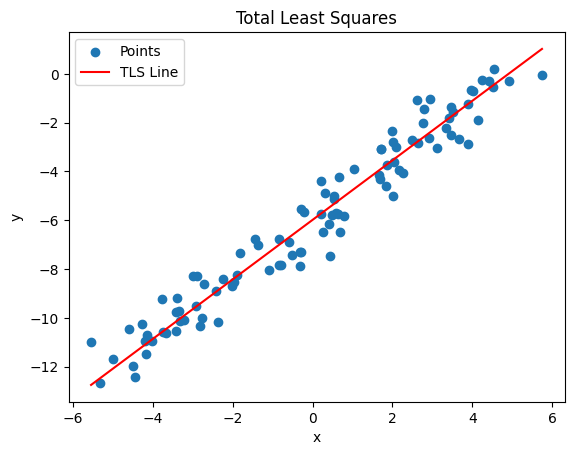

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Load dataset

D = np.genfromtxt('lines.csv', delimiter=',', skip_header=1)

# First line data

x = D[:, 0]
y = D[:, 3]

# Compute centroid

x_mean = np.mean(x)
y_mean = np.mean(y)

# Center points

X = np.column_stack((x - x_mean, y - y_mean))

# SVD

U, S, Vt = np.linalg.svd(X)

# Direction vector

direction = Vt[0]

# Line parameters

m = direction[1] / direction[0]
c = y_mean - m * x_mean

print("TLS Line:")
print("y = {:.3f}x + {:.3f}".format(m, c))

# Plot

plt.scatter(x, y, label='Points')

x_line = np.linspace(min(x), max(x), 100)
y_line = m * x_line + c

plt.plot(x_line, y_line, 'r', label='TLS Line')

plt.legend()
plt.title('Total Least Squares')
plt.xlabel('x')
plt.ylabel('y')

plt.show()


Line 1: y = 0.339x + 1.547
Line 2: y = 1.180x + -5.991
Line 3: y = 0.051x + 4.433


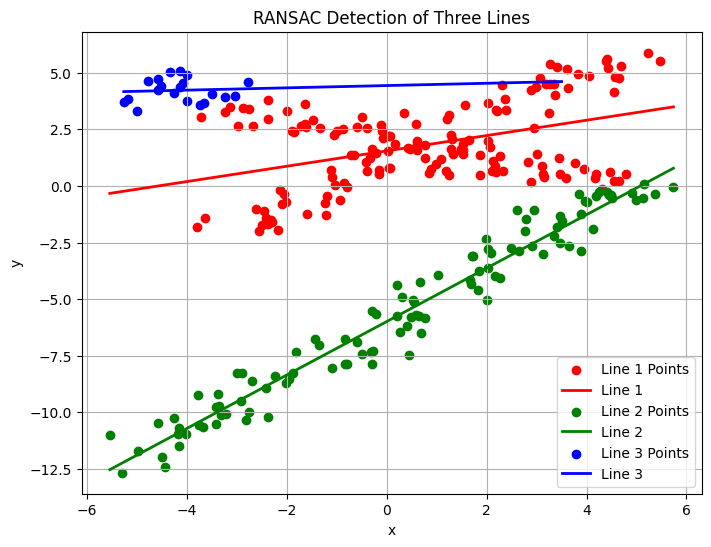

In [14]:
# ques1 (b)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression

# Load dataset
D = np.genfromtxt('lines.csv', delimiter=',', skip_header=1)

# Combine all points
X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

# Reshape for sklearn
X_all = X_all.reshape(-1, 1)

remaining_X = X_all
remaining_Y = Y_all

colors = ['red', 'green', 'blue']

plt.figure(figsize=(8,6))

for i in range(3):

    # Create model
    ransac = RANSACRegressor(LinearRegression())

    # Fit model
    ransac.fit(remaining_X, remaining_Y)

    # Get inliers
    inlier_mask = ransac.inlier_mask_

    # Line parameters
    m = ransac.estimator_.coef_[0]
    c = ransac.estimator_.intercept_

    print(f"Line {i+1}: y = {m:.3f}x + {c:.3f}")

    # Plot points
    plt.scatter(
        remaining_X[inlier_mask],
        remaining_Y[inlier_mask],
        color=colors[i],
        label=f'Line {i+1} Points'
    )

    # Plot line
    x_line = np.linspace(
        remaining_X.min(),
        remaining_X.max(),
        100
    )

    y_line = m * x_line + c

    plt.plot(
        x_line,
        y_line,
        color=colors[i],
        linewidth=2,
        label=f'Line {i+1}'
    )

    # Remove inliers
    remaining_X = remaining_X[~inlier_mask]
    remaining_Y = remaining_Y[~inlier_mask]

plt.title('RANSAC Detection of Three Lines')
plt.xlabel('x')
plt.ylabel('y')

plt.legend()
plt.grid(True)

plt.show()


Line 1: y = -0.480x + 1.806
Line 2: y = 1.648x + -4.938
Line 3: y = 1.095x + 1.185


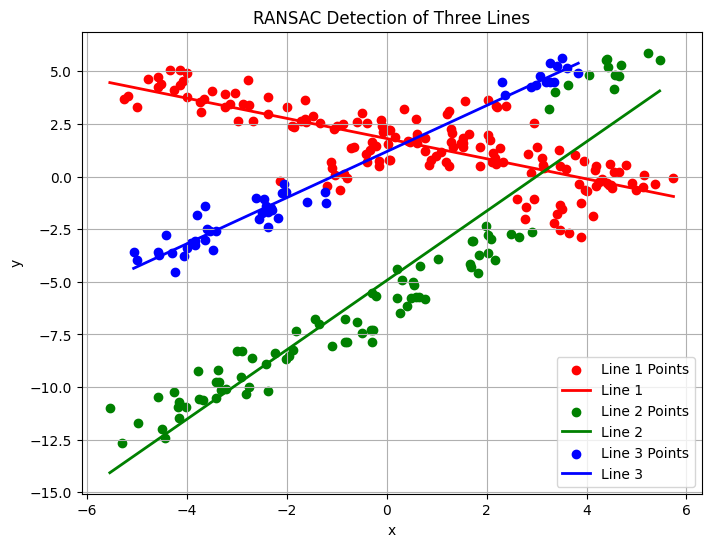

In [17]:
# Question 2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression

# Load dataset
D = np.genfromtxt('lines.csv', delimiter=',', skip_header=1)

# Combine all points
X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

# Reshape for sklearn
X_all = X_all.reshape(-1, 1)

remaining_X = X_all
remaining_Y = Y_all

colors = ['red', 'green', 'blue']

plt.figure(figsize=(8,6))

for i in range(3):

    # Create model
    ransac = RANSACRegressor(LinearRegression())

    # Fit model
    ransac.fit(remaining_X, remaining_Y)

    # Get inliers
    inlier_mask = ransac.inlier_mask_

    # Line parameters
    m = ransac.estimator_.coef_[0]
    c = ransac.estimator_.intercept_

    print(f"Line {i+1}: y = {m:.3f}x + {c:.3f}")

    # Plot points
    plt.scatter(
        remaining_X[inlier_mask],
        remaining_Y[inlier_mask],
        color=colors[i],
        label=f'Line {i+1} Points'
    )

    # Plot line
    x_line = np.linspace(
        remaining_X.min(),
        remaining_X.max(),
        100
    )

    y_line = m * x_line + c

    plt.plot(
        x_line,
        y_line,
        color=colors[i],
        linewidth=2,
        label=f'Line {i+1}'
    )

    # Remove inliers
    remaining_X = remaining_X[~inlier_mask]
    remaining_Y = remaining_Y[~inlier_mask]

plt.title('RANSAC Detection of Three Lines')
plt.xlabel('x')
plt.ylabel('y')

plt.legend()
plt.grid(True)

plt.show()

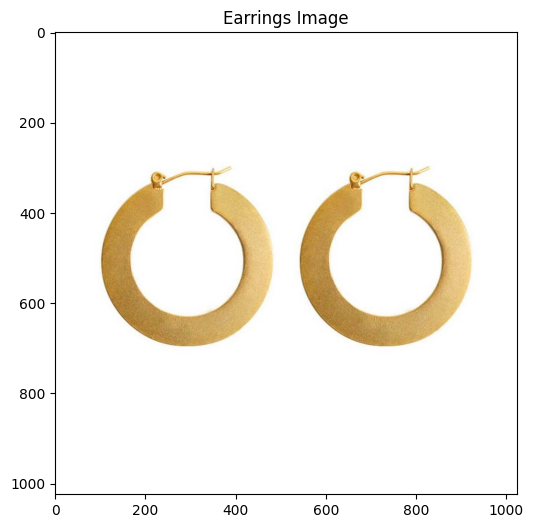

In [18]:
# Question 2
import cv2
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('earrings.jpg')

# Convert to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display image
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title('Earrings Image')
plt.axis('on')

plt.show()

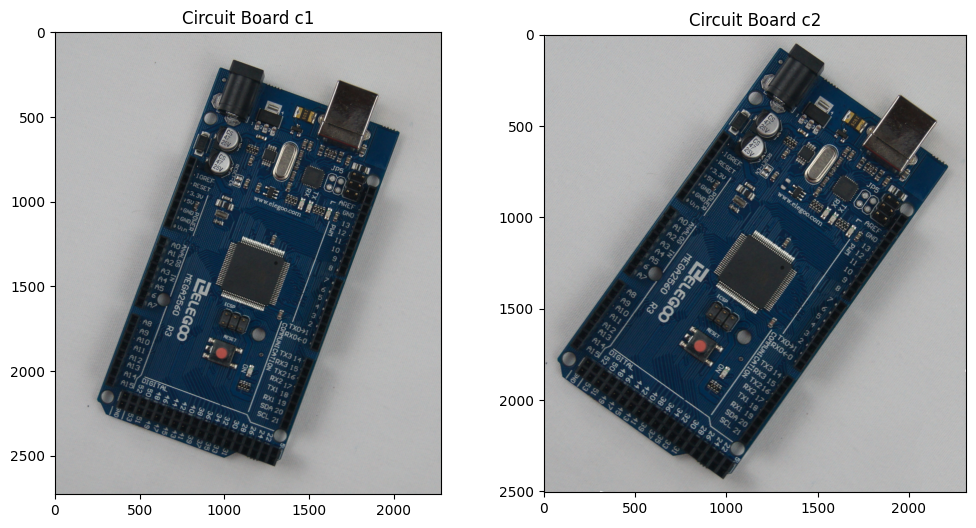

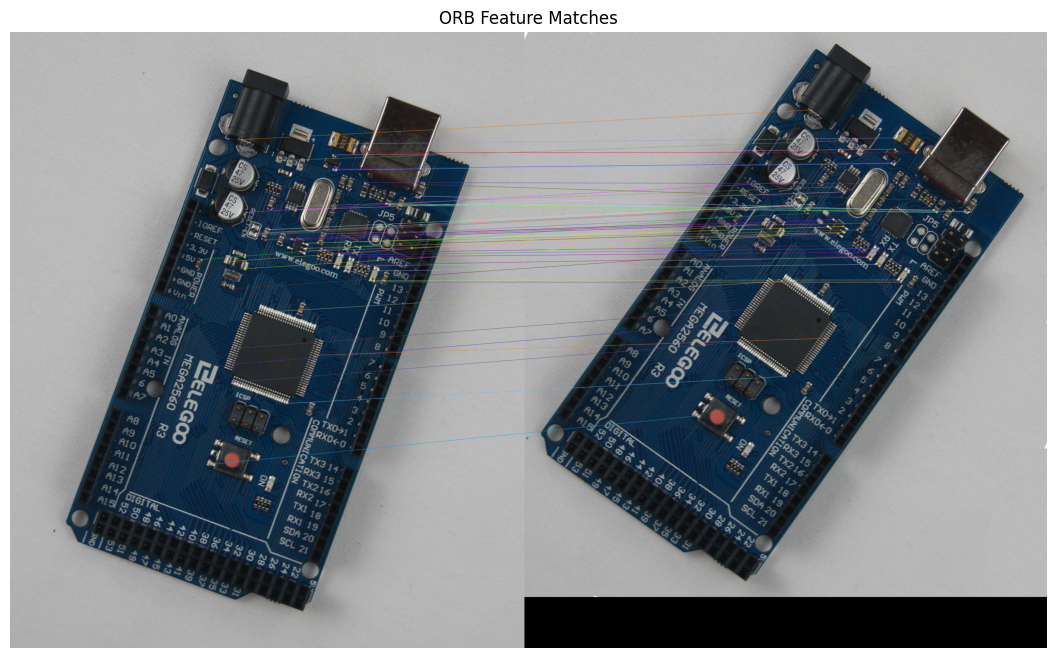

In [21]:
# Question 3
import cv2
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread('c1.jpg')
img2 = cv2.imread('c2.jpg')

# Convert to RGB
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Display images
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img1_rgb)
plt.title('Circuit Board c1')

plt.subplot(1,2,2)
plt.imshow(img2_rgb)
plt.title('Circuit Board c2')

plt.show()

# Question 3(a)
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread('c1.jpg')
img2 = cv2.imread('c2.jpg')

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ORB detector
orb = cv2.ORB_create(1000)

# Detect keypoints and descriptors
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# Match descriptors
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Sort matches
matches = sorted(matches, key=lambda x: x.distance)

# Draw matches
match_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    matches[:50],
    None,
    flags=2
)

# Display
plt.figure(figsize=(15,8))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title('ORB Feature Matches')
plt.axis('off')
plt.show()

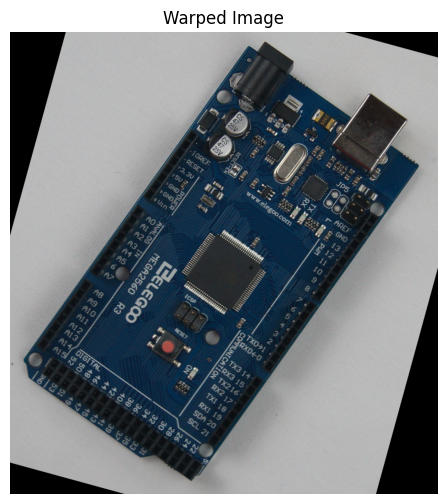

In [23]:
# Question 3 (B)
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread('c1.jpg')
img2 = cv2.imread('c2.jpg')

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ORB detector
orb = cv2.ORB_create(1000)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# Match descriptors
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

# Extract matched points
src_pts = np.float32(
    [kp1[m.queryIdx].pt for m in matches]
).reshape(-1,1,2)

dst_pts = np.float32(
    [kp2[m.trainIdx].pt for m in matches]
).reshape(-1,1,2)

# Compute homography
H, mask = cv2.findHomography(
    src_pts,
    dst_pts,
    cv2.RANSAC,
    5.0
)

# Warp image
height, width = img2.shape[:2]

warped = cv2.warpPerspective(
    img1,
    H,
    (width, height)
)

# Show warped image
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title('Warped Image')
plt.axis('off')
plt.show()

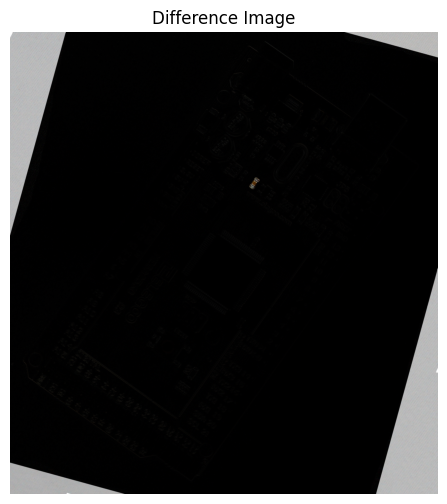

In [24]:
# question 3c
import cv2
import matplotlib.pyplot as plt

# Difference image
diff = cv2.absdiff(warped, img2)

# Display
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(diff, cv2.COLOR_BGR2RGB))
plt.title('Difference Image')
plt.axis('off')
plt.show()